In [1]:
!pip install mrcfile

In [2]:
import mrcfile
import numpy as np
import random
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
from jax import vmap, lax
from jax.tree_util import tree_map
from functools import partial
import re

In [3]:
def resize_stack_numpy(I_np, new_size=128):
    """
    Resize a stack of images from (N, X, Y) to (N, new_size, new_size)
    using bilinear interpolation.
    """
    N, X, Y = I_np.shape
    scale_x = new_size / X
    scale_y = new_size / Y
    I_resized = np.empty((N, new_size, new_size), dtype=I_np.dtype)
    for i in range(N):
        I_resized[i] = zoom(I_np[i], (scale_x, scale_y), order=1)
    return I_resized

In [4]:
I = mrcfile.read("images.mrcs")
I = resize_stack_numpy(I, new_size=128)
print(I.shape)

(12, 128, 128)


In [5]:
def show_obs_vs_sim(
    I_np,
    theta,
    R_syms,
    sigma_pix: float,
    *,
    savepath: str | None = None,
    dpi: int = 120,
    cmap: str = "gray",
    equal_scale: bool = False,
    scale_pred: bool = False,      # if True, multiply pred by global 'a' before plotting
):
    """
    Display observed (left) and simulated (right) images using the
    differentiable Gaussian-sum renderer.

    Parameters
    ----------
    I_np : (N, X, Y) array-like
        Observed images.
    theta : dict
        {'mu3': (K,3), 'quats': (N,4), 'shifts': (N,2)}
    sigma_pix : float
        Gaussian std-dev (pixels) for the renderer.
    savepath : str or None
        If provided, saves the figure here.
    dpi : int
        Figure DPI if saving.
    cmap : str
        Colormap for imshow.
    equal_scale : bool
        If True, use the same vmin/vmax for each Obs/Sim pair.
    scale_pred : bool
        If True, compute a global least-squares factor 'a' so that
        a * pred ≈ I (over all pixels/slices) and display a*pred.

    Returns
    -------
    fig : matplotlib.figure.Figure
    pred : np.ndarray, shape (N, X, Y)
        Raw (unscaled) predictions from the renderer.
    a : float
        Global scale factor used (1.0 if scale_pred=False).
    """
    I = np.asarray(I_np, dtype=np.float32)
    N, X, Y = I.shape

    # Render with the differentiable Gaussian-sum renderer (JAX → NumPy)
    pred = np.array(render_gaussian_sum(theta, int(X), int(Y), float(sigma_pix),
                                        R_syms))  # (N,X,Y)

    # Optional global least-squares scaling: a = sum(I*P)/sum(P^2)
    if scale_pred:
        num = float(np.sum(I * pred))
        den = float(np.sum(pred * pred) + 1e-12)
        a = num / den
        pred_disp = a * pred
    else:
        a = 1.0
        pred_disp = pred

    # Plot
    fig, axes = plt.subplots(N, 2, figsize=(6, 3*N), squeeze=False)
    for i in range(N):
        if equal_scale:
            vmin = float(min(I[i].min(), pred_disp[i].min()))
            vmax = float(max(I[i].max(), pred_disp[i].max()))
        else:
            vmin = vmax = None

        axL = axes[i, 0]; axR = axes[i, 1]
        axL.imshow(I[i], cmap=cmap, vmin=vmin, vmax=vmax, origin="upper")
        axL.set_title(f"Obs #{i}")
        axL.axis("off")

        axR.imshow(pred_disp[i], cmap=cmap, vmin=vmin, vmax=vmax, origin="upper")
        axR.set_title(f"Sim #{i}" + (f"  (a={a:.3g})" if (scale_pred and i==0) else ""))
        axR.axis("off")

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", dpi=dpi)

    return fig, pred, a

Plain Simulated annealing

In [6]:
import numpy as np
def _rodrigues(axis: np.ndarray, angle: float) -> np.ndarray:
    """3x3 rotation using Rodrigues' formula (numpy, then cast to jax later)."""
    a = axis / (np.linalg.norm(axis) + 1e-12)
    x, y, z = a
    c = np.cos(angle)
    s = np.sin(angle)
    C = 1.0 - c
    return np.array([
        [c + x*x*C,     x*y*C - z*s,  x*z*C + y*s],
        [y*x*C + z*s,   c + y*y*C,    y*z*C - x*s],
        [z*x*C - y*s,   z*y*C + x*s,  c + z*z*C  ],
    ], dtype=np.float32)

def _uniq_stack(mats, tol=1e-6):
    """Deduplicate rotation matrices up to a tolerance."""
    uniq = []
    keys = set()
    for M in mats:
        key = tuple(np.round(M.reshape(-1), 6))  # hashable with rounding
        if key not in keys:
            keys.add(key)
            uniq.append(M)
    return np.stack(uniq, axis=0)

def _is_proper_rot(M, tol=1e-5):
    return (np.allclose(M.T @ M, np.eye(3), atol=tol) and
            np.isclose(np.linalg.det(M), 1.0, atol=tol))

# --- generators for each symmetry ---------------------------------
def _cn(n: int, axis=np.array([0., 0., 1.], dtype=np.float32)) -> np.ndarray:
    """C_n rotations about 'axis'."""
    mats = [_rodrigues(axis, 2*np.pi*k/n) for k in range(n)]
    return _uniq_stack(mats)

def _dn(n: int, axis=np.array([0., 0., 1.], dtype=np.float32)) -> np.ndarray:
    """D_n = rotations about primary axis (n of them) + n 2-folds orthogonal."""
    # Primary Cn about 'axis'
    Rz = _cn(n, axis)
    # Pick any axis orthogonal to 'axis'; build a π-rotation around it,
    # then conjugate by Rz^k to sweep the n distinct 2-fold axes.
    # Choose x-axis projected orthogonal to 'axis'.
    z = axis / (np.linalg.norm(axis) + 1e-12)
    # If z ≈ e_z, use x; else pick cross with e_z to get an orthonormal x-like vector
    ez = np.array([0., 0., 1.], dtype=np.float32)
    trial = np.cross(z, ez)
    if np.linalg.norm(trial) < 1e-6:
        ortho = np.array([1., 0., 0.], dtype=np.float32)
    else:
        ortho = trial / (np.linalg.norm(trial) + 1e-12)

    Rpi = _rodrigues(ortho, np.pi)           # a single 180° about some orthogonal axis
    # Build the n distinct 2-folds: Rz(k) * Rpi * Rz(-k)
    Rz_inv = np.transpose(Rz, (0, 2, 1))
    two_folds = [Rz[k] @ Rpi @ Rz_inv[k] for k in range(n)]
    mats = list(Rz) + two_folds
    return _uniq_stack(mats)

def _octahedral() -> np.ndarray:
    """Proper rotations of the cube/octahedron: all 3x3 signed permutation matrices with det=1."""
    mats = []
    # All permutations of axes with sign flips such that determinant == +1
    axes = np.eye(3, dtype=np.float32)
    from itertools import permutations, product
    for perm in permutations(range(3)):
        P = axes[list(perm), :]
        for signs in product([-1., 1.], repeat=3):
            M = (P.T * np.array(signs, dtype=np.float32)).T
            if _is_proper_rot(M):
                mats.append(M)
    return _uniq_stack(mats)

def _icosahedral() -> np.ndarray:
    """
    Proper icosahedral group (60 elements).
    Construct via group generators: a 5-fold, a 3-fold, and a 2-fold rotation,
    then close under multiplication.
    """
    phi = (1.0 + np.sqrt(5.0)) / 2.0

    # Use standard axes for an icosahedron:
    # 5-fold axis through (0, 1, φ)
    a5 = np.array([0., 1., phi], dtype=np.float32)
    a5 /= np.linalg.norm(a5) + 1e-12

    # 3-fold axis through (1, 1, 1)
    a3 = np.array([1., 1., 1.], dtype=np.float32)
    a3 /= np.linalg.norm(a3) + 1e-12

    # 2-fold axis along x
    a2 = np.array([1., 0., 0.], dtype=np.float32)

    R5 = _rodrigues(a5, 2*np.pi/5.0)   # 72°
    R3 = _rodrigues(a3, 2*np.pi/3.0)   # 120°
    R2 = _rodrigues(a2, np.pi)         # 180°

    gens = [R5, R3, R2]

    # BFS/closure to size 60, deduplicating by rounding
    mats = [np.eye(3, dtype=np.float32)]
    keys = {tuple(np.round(mats[0].reshape(-1), 6))}
    frontier = [mats[0]]
    while frontier and len(mats) < 60:
        new_frontier = []
        for A in frontier:
            for G in gens:
                B = A @ G
                key = tuple(np.round(B.reshape(-1), 6))
                if key not in keys:
                    if _is_proper_rot(B):
                        keys.add(key)
                        mats.append(B)
                        new_frontier.append(B)
        frontier = new_frontier

    # If for numerical reasons we ended short, do a second pass multiplying gens on the left
    if len(mats) < 60:
        frontier = [np.eye(3, dtype=np.float32)]
        while frontier and len(mats) < 60:
            new_frontier = []
            for A in frontier:
                for G in gens:
                    B = G @ A
                    key = tuple(np.round(B.reshape(-1), 6))
                    if key not in keys:
                        if _is_proper_rot(B):
                            keys.add(key)
                            mats.append(B)
                            new_frontier.append(B)
            frontier = new_frontier

    mats = _uniq_stack(mats)
    assert mats.shape[0] in (60,), f"Expected 60 icosahedral rotations, got {mats.shape[0]}"
    return mats

def makeRotations(symStr: str = 'c1') -> jnp.ndarray:
    """
    Return (S,3,3) JAX array of proper rotation matrices for the given symmetry:
      'cN'  cyclic, N >= 1
      'dN'  dihedral, N >= 2
      'o'   octahedral (24)
      'i1'  icosahedral (60)
      'c1'  identity (1)

    Examples: 'C1', 'c7', 'D5', 'o', 'I1'
    """
    s = symStr.strip().lower()

    # cN
    m = re.fullmatch(r'c(\d+)', s)
    if m:
        n = int(m.group(1))
        assert n >= 1
        mats = _cn(n)
        return jnp.asarray(mats)

    # dN
    m = re.fullmatch(r'd(\d+)', s)
    if m:
        n = int(m.group(1))
        assert n >= 2
        mats = _dn(n)
        return jnp.asarray(mats)

    # octahedral
    if s in ('o', 'oct', 'octa', 'octahedral'):
        mats = _octahedral()
        return jnp.asarray(mats)

    # icosahedral (I1)
    if s in ('i1', 'i', 'icos', 'ico', 'icosahedral'):
        mats = _icosahedral()
        return jnp.asarray(mats)

    # default / c1
    if s in ('c1', 'c01', '1', 'identity'):
        return jnp.asarray(np.eye(3, dtype=np.float32)[None, ...])

    raise ValueError(f"Unsupported symmetry string: {symStr!r}")

In [7]:
# --------- Quaternion helpers ----------
def normalize_quat(q):
    return q / (jnp.linalg.norm(q) + 1e-12)

def axis_angle_to_quat(axis, angle):
    axis = axis / (jnp.linalg.norm(axis) + 1e-12)
    s = jnp.sin(angle/2.0)
    return jnp.array([jnp.cos(angle/2.0), axis[0]*s, axis[1]*s, axis[2]*s])

def quat_mul(q1, q2):
    w1,x1,y1,z1 = q1
    w2,x2,y2,z2 = q2
    return jnp.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def quat_to_R(q):
    w,x,y,z = q
    return jnp.array([
        [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)],
    ])

# --------- Centered 2D marginal of unit-mass 3D isotropic Gaussian ----------
def project_points_all_images(mu3_base, quats, shifts, X, Y, R_syms):
    """
    mu3_base: (K,3)   asymmetric-unit centers (centered coords)
    quats:    (N,4)
    shifts:   (N,2)
    R_syms:   (S,3,3) symmetry rotation matrices (world frame)
    return:   (N, K*S, 2) projected coords of all symmetrized copies
    """
    # per-image rotation
    Rs = vmap(quat_to_R)(quats)                          # (N,3,3)

    # compose with each symmetry op: R_eff = R @ S
    # shape: (N,S,3,3)
    R_eff = jnp.einsum('nij,sjk->nsik', Rs, R_syms)

    # We need (R_eff)^T for right-multiply by mu3
    R_eff_T = jnp.swapaxes(R_eff, -1, -2)                # (N,S,3,3)

    # Apply to all sym ops, then flatten S*K
    # p3: (N,S,K,3) = mu3 (K,3) @ (R_eff)^T (N,S,3,3)
    p3 = jnp.einsum('kj,nsji->nski', mu3_base, R_eff_T)

    # Take x,y and add center + shift
    center2 = jnp.array([X/2, Y/2], jnp.float32)
    p2 = p3[..., :2] + center2[None,None,None,:] + shifts[:,None,None,:]  # (N,S,K,2)

    # reshape to (N, K*S, 2)
    N, S, K, _ = p2.shape
    return p2.reshape((N, S*K, 2))

@partial(jax.jit, static_argnames=("X","Y"))
def splat_points_nearest(pts, X: int, Y: int):
    # pts: (K,2)
    xi = jnp.rint(pts[:, 0]).astype(jnp.int32)
    yi = jnp.rint(pts[:, 1]).astype(jnp.int32)
    xi = jnp.clip(xi, 0, X - 1)
    yi = jnp.clip(yi, 0, Y - 1)

    idx = xi * Y + yi
    w   = jnp.full((pts.shape[0],), 1.0, dtype=jnp.float32)

    flat = jnp.bincount(idx, weights=w, length=X * Y)  # length is static now
    return flat.reshape((X, Y))

@partial(jax.jit, static_argnames=("X","Y"))
def render_gaussian_sum(theta, X:int, Y:int, sigma_pix:float, R_syms:jnp.ndarray):
    """
    theta: {'mu3':(K,3), 'quats':(N,4), 'shifts':(N,2)}
    R_syms: (S,3,3)
    return: (N,X,Y) sum of Gaussians over all symmetry copies
    """
    # σ guard
    sigma = jnp.maximum(jnp.asarray(sigma_pix, jnp.float32), 1e-3)
    inv2s2 = 0.5 / (sigma * sigma)

    # all symmetrized projected points: (N, K*S, 2)
    pts_all = project_points_all_images(
        theta["mu3"], theta["quats"], theta["shifts"], X, Y, R_syms
    )

    xs = jnp.arange(X); ys = jnp.arange(Y)
    Xg, Yg = jnp.meshgrid(xs, ys, indexing="ij")
    grid = jnp.stack([Xg, Yg], axis=-1).astype(jnp.float32)  # (X,Y,2)

    def render_one(pts):  # pts: (K*S,2)
        diffs = pts[:, None, None, :] - grid[None, :, :, :]  # (KS,X,Y,2)
        d2 = jnp.sum(diffs * diffs, axis=-1)                 # (KS,X,Y)
        ex = jnp.clip(-inv2s2 * d2, a_min=-80.0, a_max=0.0)
        gaus = jnp.exp(ex)
        return jnp.sum(gaus, axis=0)                         # (X,Y)

    return vmap(render_one)(pts_all)                         # (N,X,Y)

# --------- Correlation loss (average per image) ----------
def corr_per_image(I, P, eps=1e-8):
    N = I.shape[0]
    I_flat = I.reshape(N, -1); P_flat = P.reshape(N, -1)
    I0 = I_flat - jnp.mean(I_flat, axis=1, keepdims=True)
    P0 = P_flat - jnp.mean(P_flat, axis=1, keepdims=True)
    num = jnp.sum(I0 * P0, axis=1)
    den = jnp.sqrt(jnp.sum(I0**2, axis=1) * jnp.sum(P0**2, axis=1)) + eps
    return num / den

def loss_corr_gauss(theta, I, sigma_pix, R_syms, eps=1e-6):
    N, X, Y = I.shape
    P = render_gaussian_sum(theta, X, Y, sigma_pix, R_syms)

    I_f = I.reshape(N, -1); P_f = P.reshape(N, -1)
    I_m = jnp.mean(I_f, axis=1, keepdims=True)
    P_m = jnp.mean(P_f, axis=1, keepdims=True)
    I_s = jnp.maximum(jnp.sqrt(jnp.mean((I_f - I_m)**2, axis=1, keepdims=True)), eps)
    P_s = jnp.maximum(jnp.sqrt(jnp.mean((P_f - P_m)**2, axis=1, keepdims=True)), eps)

    r = jnp.mean(((I_f - I_m)/I_s) * ((P_f - P_m)/P_s), axis=1)  # (N,)
    return 1.0 - jnp.mean(r)

def init_theta_SA(I_np, K=64, seed=0):
    """
    Initialize the parameter vector for Simulated Annealing.

    mu3: random 3D coordinates centered around (0,0,0),
         typically in a cube of side ~image_size.
    quats: all identity (no rotation)
    shifts: all zeros (no in-plane translation)
    """
    I = jnp.asarray(I_np, dtype=jnp.float32)
    N, X, Y = I.shape
    key = jax.random.PRNGKey(seed)

    # Initialize quaternions
    q = jax.random.normal(key, (N, 4))
    q = q / (jnp.linalg.norm(q, axis=1, keepdims=True) + 1e-12)
    quats=q.astype(jnp.float32)

    # Zero shifts
    shifts = jnp.zeros((N, 2), dtype=jnp.float32)

    # Centered 3D coordinates for K Gaussians
    # Spread around origin with typical range [-0.5*X, 0.5*X]
    spread_x = 0.2 * X
    spread_y = 0.2 * Y
    spread_z = 0.2 * min(X, Y)

    keyx, keyy, keyz = jax.random.split(key, 3)
    mu3 = jnp.stack([
        spread_x * jax.random.uniform(keyx, (K,), minval=-1.0, maxval=1.0),
        spread_y * jax.random.uniform(keyy, (K,), minval=-1.0, maxval=1.0),
        spread_z * jax.random.uniform(keyz, (K,), minval=-1.0, maxval=1.0),
    ], axis=1)

    # No need for a pixel grid now (optional)
    theta = {"quats": quats, "shifts": shifts, "mu3": mu3}
    grid_xy = None  # kept for compatibility

    return theta, grid_xy

# --------- Pure SA over ALL params: images + all Gaussians ----------
def recenter_mixture(theta):
    """
    Recenters the 3D centers so their mean is at the origin (in absolute pixel coords)
    and compensates per-image shifts so rendered projections stay unchanged.

    Projection we use is:
      p2d = S @ (R @ (mu3 - center3)) + center2 + t
    If we move mu3' = mu3 - d, to keep p2d fixed we must set:
      t' = t + S @ (R @ d)
    (note the **plus** sign).
    """
    mu3   = theta["mu3"]              # (K,3)
    quats = theta["quats"]            # (N,4)
    shifts= theta["shifts"]           # (N,2)

    # mean (equal weights)
    d = jnp.mean(mu3, axis=0)         # (3,)
    mu3_new = mu3 - d[None, :]

    return {**theta, "mu3": mu3_new}

def plot_sa_progress(E_hist_host):
    losses = np.array(E_hist_host)
    fig, ax1 = plt.subplots(figsize=(6,4))

    ax1.plot(range(losses.size), losses, '-', color='tab:blue', label='Loss vs iterations')

    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_title('Simulated Annealing Progress')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def sa_optimize_all(
    I_np, theta0, Rsyms, *,
    sigma_pix=4.0,                   # Gaussian width in pixels
    n_outer=200, iters_per_temp=None, T0=1.0, Tmin=1e-3,
    rot_step=0.05, shift_step=0.5, mu_step=1.0,
    max_shift_pix=10,
    key_seed=0
):
    I = jnp.asarray(I_np, dtype=jnp.float32)
    N, X, Y = I.shape
    K = int(theta0["mu3"].shape[0])
    if iters_per_temp is None:
        iters_per_temp = N + K

    temps = jnp.asarray(jnp.geomspace(T0, Tmin, n_outer), dtype=I.dtype)
    T0_j = jnp.asarray(T0, I.dtype)
    key = jax.random.PRNGKey(key_seed)
    energy = jax.jit(lambda th: loss_corr_gauss(th, I, sigma_pix, R_syms))

    # --- helpers --------------------------------------------------
    p_global_rot0 = 0.20   # base prob of global rotation jump
    p_global_mu0  = 0.20   # base prob of global mu3 jump

    # anneal helper: higher at high T (scale≈1), lower at low T (scale→0)
    def anneal_p(p0, scale):
        # p(scale) in [0.5*p0, 1.0*p0]; linear is fine (smooth, JIT-friendly)
        return p0 # COSS: * (0.5 + 0.5*scale)

    # bounds for global mu3 redraws (centered box); use your coordinate range
    R_mu = 0.5 * jnp.float32(min(X, Y))  # if mu3 are already centered in [-X/2, X/2]

    def _upd_row(arr, i, row):  return lax.dynamic_update_slice(arr, row[jnp.newaxis, :], (i, 0))
    def _upd_row2(arr, i, row): return lax.dynamic_update_slice(arr, row[jnp.newaxis, :], (i, 0))
    def _upd_row3(arr, k, row): return lax.dynamic_update_slice(arr, row[jnp.newaxis, :], (k, 0))

    def dq_small(axis, angle):
        v = 0.5 * angle * axis
        return jnp.concatenate([jnp.array([1.0], dtype=v.dtype), v], axis=0)

    def rand_unit_quat(key):
        q = jax.random.normal(key, (4,))
        return q / (jnp.linalg.norm(q) + 1e-12)

    # ----------------- proposals -----------------
    def propose_image(th, i, k_rot, k_shift, k_aux, scale):
        """
        Rotations: local small-angle OR global redraw (prob annealed with scale).
        Shifts:    local only (Gaussian jitter).
        """
        # rotation
        k_axis, k_ang, k_qglob, k_u = jax.random.split(k_rot, 4)
        axis  = jax.random.normal(k_axis, (3,))
        axis  = axis / (jnp.linalg.norm(axis) + 1e-12)
        angle = (rot_step * scale) * jax.random.normal(k_ang, ())
        dq    = dq_small(axis, angle)

        q_old = th["quats"][i]
        q_loc = normalize_quat(quat_mul(dq, q_old))   # local step
        q_glb = rand_unit_quat(k_qglob)               # global redraw

        p_rot = anneal_p(p_global_rot0, scale)        # higher at high T
        do_glb_rot = (jax.random.uniform(k_u, ()) < p_rot)
        q_new = lax.select(do_glb_rot, q_glb, q_loc)

        # shift (local only)
        t_new = th["shifts"][i] + (shift_step * scale) * jax.random.normal(k_shift, (2,))
        t_new = jnp.clip(t_new, -max_shift_pix, max_shift_pix)

        return {
            "quats":  _upd_row(th["quats"],  i, q_new),
            "shifts": _upd_row2(th["shifts"], i, t_new),
            "mu3":    th["mu3"],
        }

    def propose_mu(th, k, k_mu, k_aux, scale):
        """
        mu3: local Gaussian step OR global redraw in centered cube [-R_mu,R_mu]^3,
        with annealed probability.
        """
        mu_loc = th["mu3"][k] + (mu_step * scale) * jax.random.normal(k_mu, (3,))
        u3     = jax.random.uniform(k_aux, (3,), minval=-1.0, maxval=1.0)
        mu_glb = R_mu * u3

        p_mu = anneal_p(p_global_mu0, scale)
        do_glb = (jax.random.uniform(k_mu, ()) < p_mu)
        mu_new = lax.select(do_glb, mu_glb, mu_loc)

        return {
            "quats":  th["quats"],
            "shifts": th["shifts"],
            "mu3":    _upd_row3(th["mu3"], k, mu_new),
        }

    def select_theta(mask, a, b):
        return {
            "quats":  lax.select(mask, b["quats"],  a["quats"]),
            "shifts": lax.select(mask, b["shifts"], a["shifts"]),
            "mu3":    lax.select(mask, b["mu3"],    a["mu3"]),
        }

    # --- main compiled run ----------------------------------------
    @partial(jax.jit, donate_argnums=(0,))
    def run_all(theta_init, key, temps):
        E_init = energy(theta_init)

        def outer_body(carry, T):
            th, E_curr, key = carry
            scale = jnp.sqrt(jnp.maximum(T, 1e-12) / jnp.maximum(T0_j, 1e-12))

            def inner_body(inner_carry, _):
                th_i, E_i, key_i = inner_carry
                key_i, k_choice, k_i, k_k, k_r, k_s, k_m, k_u, k_aux1, k_aux2 = jax.random.split(key_i, 10)

                is_image = jax.random.uniform(k_choice, ()) < N/(N+K)
                ii = jax.random.randint(k_i, (), 0, N)
                kk = jax.random.randint(k_k, (), 0, K)

                th_img = propose_image(th_i, ii, k_r, k_s, k_aux1, scale)  # shifts local
                th_mu  = propose_mu(  th_i, kk, k_m, k_aux2, scale)        # mu3 can jump
                th_prop = select_theta(is_image, th_mu, th_img)
                E_prop = energy(th_prop)
                dE = E_prop - E_i
                u = jax.random.uniform(k_u, ())
                accept = (dE <= 0) | (u < jnp.exp(-dE / jnp.maximum(T, 1e-12)))
                th_next = select_theta(accept, th_i, th_prop)
                E_next  = lax.select(accept, E_prop, E_i)
                return (th_next, E_next, key_i), None

            (th1, E1, key1), _ = lax.scan(inner_body, (th, E_curr, key), None, length=iters_per_temp)
            th1 = recenter_mixture(th1)
            E1  = energy(th1)
            return (th1, E1, key1), E1

        (theta_f, E_f, key_f), E_hist = lax.scan(outer_body, (theta_init, E_init, key), temps)
        return theta_f, E_f, key_f, E_hist

    theta_f, E_f, key, E_hist = run_all(theta0, key, temps)

    E_hist_host = np.array(E_hist)  # move to CPU
    temps_host = np.array(temps)

    plot_sa_progress(E_hist_host)

    # print("\n[SA] Evolution:")
    # for t, (T, E) in enumerate(zip(temps_host, E_hist_host)):
    #     print(f"  Iter {t+1:3d} | T={T:.6f} | loss={E:.6f}")
    print(f"[SA] done: final loss={float(E_f):.6f}")

    return theta_f, E_hist, temps

# --------- One-shot convenience wrapper ---------
def fit_with_simulated_annealing(
    I_np, Rsyms, K=60, *,
    n_outer=1000, iters_per_temp=None,
    T0=1e-3, Tmin=1e-5,
    rot_step=0.05, shift_step=0.5, mu_step=1.0,
    sigma_pix=4.0, seed=0
):
    theta0, grid_xy = init_theta_SA(I_np, K, seed=seed)
    theta_sa, E_hist, temps = sa_optimize_all(
        I_np, theta0, Rsyms,
        sigma_pix=sigma_pix,
        n_outer=n_outer, iters_per_temp=iters_per_temp,
        T0=T0, Tmin=Tmin,
        rot_step=rot_step, shift_step=shift_step, mu_step=mu_step,
        key_seed=seed
    )
    return theta_sa, grid_xy, E_hist

In [8]:
sigma_pix = 8.0
R_syms = makeRotations('c2')

In [9]:
if False:
  import cProfile, pstats
  with cProfile.Profile() as pr:
      theta_sa, grid_xy, E_hist = fit_with_simulated_annealing(I, R_syms, K=9, n_outer=100, T0=1e-2, Tmin=1e-5, sigma_pix=sigma_pix)
  pstats.Stats(pr).sort_stats("cumtime").print_stats(15)

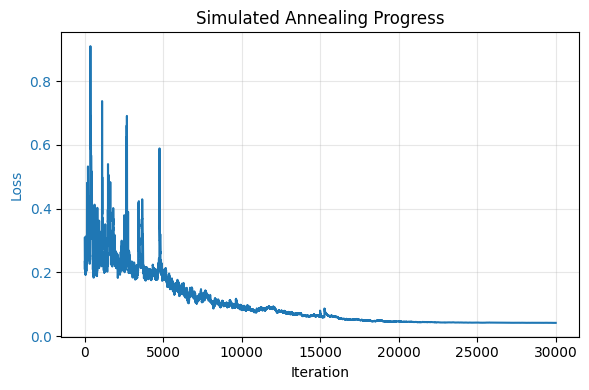

[SA] done: final loss=0.041770


In [10]:
theta_sa, grid_xy, E_hist = fit_with_simulated_annealing(I, R_syms, K=5, n_outer=30000, T0=1e-2, Tmin=1e-5, sigma_pix=sigma_pix)

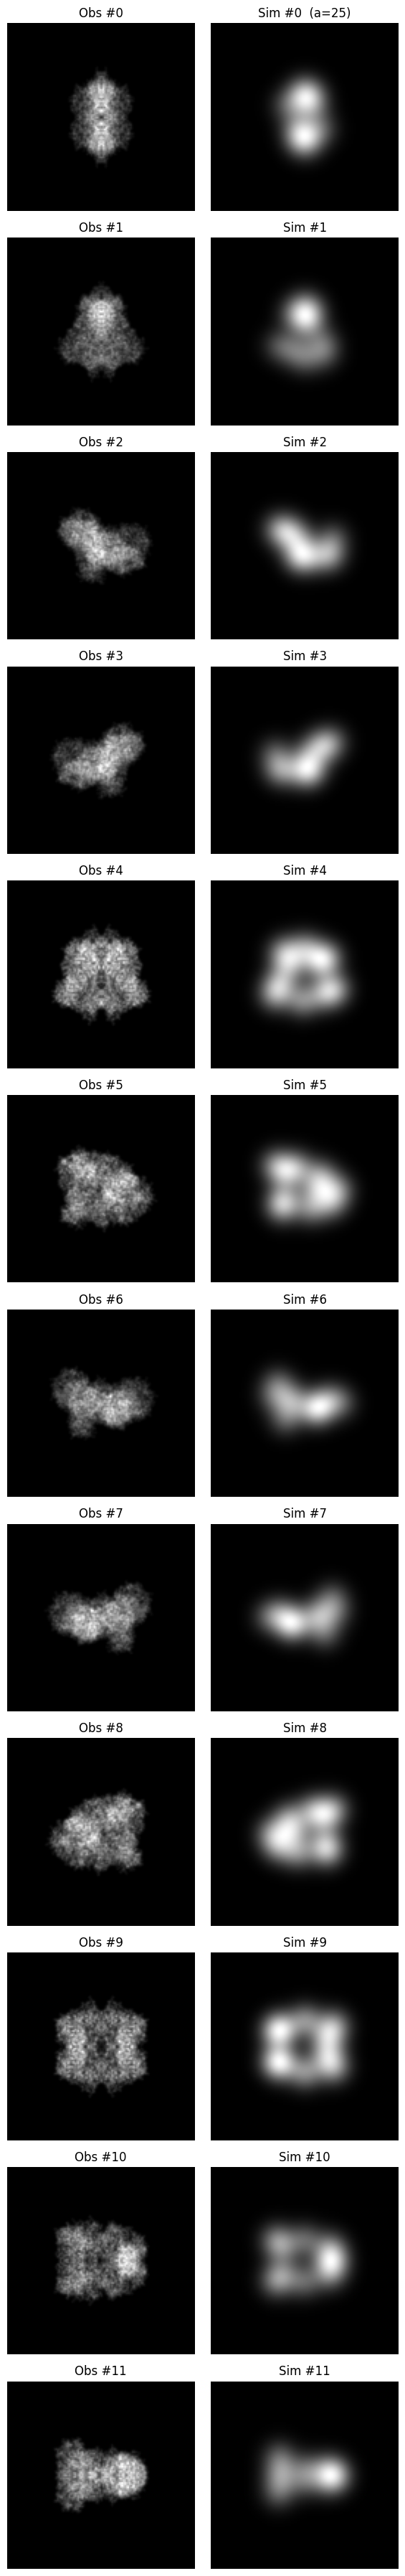

In [11]:
fig, pred, a = show_obs_vs_sim(I, theta_sa, R_syms, sigma_pix=sigma_pix,
                               savepath="obs_vs_sim.png",
                               dpi=150, equal_scale=False, scale_pred=True)

In [12]:
def remove_mu3_outliers(mu3, z=3.0, eps=1e-12):
    """
    Remove Gaussians whose nearest-neighbor distance is an outlier.
    Uses a robust threshold: thr = median(d_nn) + z * 1.4826 * MAD(d_nn).

    Args
    ----
    mu3 : of shape (K,3)
    z : float
        Robustness multiplier (3.0 is a good default).
    eps : float
        Numerical guard.

    Returns
    -------
    theta_clean
    """
    mu3 = np.asarray(mu3, dtype=np.float32)  # (K,3)
    K = mu3.shape[0]

    # Pairwise distances (K,K)
    diffs = mu3[:, None, :] - mu3[None, :, :]
    dist  = np.sqrt(np.sum(diffs**2, axis=-1))
    np.fill_diagonal(dist, np.inf)              # ignore self-dist
    d_nn = dist.min(axis=1)                     # nearest-neighbor distance per point, shape (K,)

    # Robust threshold
    med = np.median(d_nn)
    mad = np.median(np.abs(d_nn - med)) + eps
    sigma = 1.4826 * mad
    thr = med + z * sigma

    keep = d_nn <= thr

    return np.asarray(mu3[keep])

mu3clean = remove_mu3_outliers(theta_sa["mu3"], z=3.0)

In [13]:
import plotly.graph_objects as go

import jax.numpy as jnp
import numpy as np
import plotly.graph_objects as go

def show_mu3_symmetry(theta, R_syms, color_by='z'):
    """
    Visualize the Gaussian centers and all their symmetry copies in 3D.

    Parameters
    ----------
    theta : dict
        Dictionary containing at least {'mu3': (K,3)} in centered coordinates.
    R_syms : array (S,3,3)
        Rotation matrices defining the symmetry.
    color_by : str, optional
        Coordinate to color the points by: 'x', 'y', or 'z'.
    """
    mu3 = np.asarray(theta["mu3"])          # (K,3)
    R_syms = np.asarray(R_syms)             # (S,3,3)
    K = mu3.shape[0]
    S = R_syms.shape[0]

    # Compute all symmetry-related copies
    # sym_copies: (S,K,3)
    sym_copies = np.einsum('sij,kj->ski', R_syms, mu3)

    # Flatten to (S*K,3)
    all_points = sym_copies.reshape((-1, 3))

    # Separate asymmetric unit for highlighting
    base_x, base_y, base_z = mu3[:, 0], mu3[:, 1], mu3[:, 2]
    all_x, all_y, all_z = all_points[:, 0], all_points[:, 1], all_points[:, 2]

    # Color by chosen coordinate
    color_index = {'x': 0, 'y': 1, 'z': 2}[color_by]
    color_vals = all_points[:, color_index]

    fig = go.Figure()

    # Base asymmetric unit
    fig.add_trace(go.Scatter3d(
        x=all_x, y=all_y, z=all_z,
        mode='markers',
        marker=dict(
            size=6,
            color='red',
            opacity=0.9,
            symbol='circle'
        ),
        name='Asymmetric unit'
    ))

    fig.update_layout(
        title=f"Gaussian centers with {S}-fold symmetry",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()
    return fig

fig = show_mu3_symmetry(theta_sa, R_syms, color_by='z')

In [14]:
q = np.array(theta_sa["quats"], dtype=np.float32)  # shape (N,4)

def quat_to_R_np(q):
    # q: (..., 4) as [w,x,y,z]
    w, x, y, z = q[...,0], q[...,1], q[...,2], q[...,3]
    xx, yy, zz = x*x, y*y, z*z
    xy, xz, yz = x*y, x*z, y*z
    xw, yw, zw = x*w, y*w, z*w
    R = np.stack([
        np.stack([1-2*(yy+zz),   2*(xy-zw),     2*(xz+yw)], axis=-1),
        np.stack([2*(xy+zw),     1-2*(xx+zz),   2*(yz-xw)], axis=-1),
        np.stack([2*(xz-yw),     2*(yz+xw),     1-2*(xx+yy)], axis=-1),
    ], axis=-2)  # (..., 3, 3)
    return R

R = quat_to_R_np(q)                           # (N,3,3)
dirs = R @ np.array([0.0, 0.0, 1.0])          # (N,3) viewing directions

# ---- unit sphere surface for context ----
phi = np.linspace(0, np.pi, 50)
theta = np.linspace(0, 2*np.pi, 100)
pp, tt = np.meshgrid(phi, theta, indexing="ij")
xs = np.sin(pp) * np.cos(tt)
ys = np.sin(pp) * np.sin(tt)
zs = np.cos(pp)

sphere = go.Surface(
    x=xs, y=ys, z=zs,
    colorscale="Greys", showscale=False, opacity=0.2
)

# Build line segments from origin -> dirs[i] for each i
line_x, line_y, line_z = [], [], []
for v in dirs:
    line_x += [0, v[0], None]
    line_y += [0, v[1], None]
    line_z += [0, v[2], None]

arrows = go.Scatter3d(
    x=line_x, y=line_y, z=line_z,
    mode="lines",
    line=dict(width=3),
    name="Viewing directions"
)

fig = go.Figure(data=[sphere, arrows])
fig.update_layout(
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        aspectmode="data",
        xaxis=dict(range=[-1.1, 1.1]),
        yaxis=dict(range=[-1.1, 1.1]),
        zaxis=dict(range=[-1.1, 1.1]),
    ),
    width=700, height=650,
    title="Projection directions from quaternions"
)
fig.show()

In [15]:
theta_sa["shifts"]

Array([[-0.34908122, -0.22773562],
       [ 0.00179047, -0.341282  ],
       [-0.58877283, -0.14285421],
       [-0.7386659 , -0.46976367],
       [-0.42277908, -0.6218486 ],
       [-0.7809215 , -0.69919974],
       [-0.4056704 , -0.71778405],
       [-0.27059442,  0.18210568],
       [-0.71339566,  0.07702637],
       [-0.4966643 , -0.28760982],
       [-0.19117494, -0.26023182],
       [-0.3880344 ,  0.2585556 ]], dtype=float32)

In [16]:
def project_quats(theta):
    q = theta["quats"]
    q = q / (jnp.linalg.norm(q, axis=1, keepdims=True) + 1e-12)
    return {**theta, "quats": q}

def theta_tree_map(f, theta):
    return {"quats": f(theta["quats"]),
            "shifts": f(theta["shifts"]),
            "mu3": f(theta["mu3"])}

def freeze_quats(theta):
    # If you want to start by optimizing ONLY mu3 & shifts:
    return {"quats": lax.stop_gradient(theta["quats"]),
            "shifts": theta["shifts"],
            "mu3": theta["mu3"]}

def adam_init(theta):
    m = theta_tree_map(jnp.zeros_like, theta)
    v = theta_tree_map(jnp.zeros_like, theta)
    return m, v

def adam_update(theta, m, v, grads, t, lr=1e-2, b1=0.9, b2=0.999, eps=1e-8):
    m = {k: b1*m[k] + (1-b1)*grads[k] for k in m}
    v = {k: b2*v[k] + (1-b2)*(grads[k]*grads[k]) for k in v}
    mhat = {k: m[k] / (1 - b1**t) for k in m}
    vhat = {k: v[k] / (1 - b2**t) for k in v}
    theta = {k: theta[k] - lr * mhat[k] / (jnp.sqrt(vhat[k]) + eps) for k in theta}
    return theta, m, v

@partial(jax.jit, static_argnames=("n_steps","sigma_pix","optimize_quats"))
def local_refine(theta0, I, R_syms, n_steps=300, sigma_pix=4.0, lr=5e-3, optimize_quats=False):
    theta = theta0 if optimize_quats else {"quats": lax.stop_gradient(theta0["quats"]),
                                           "shifts": theta0["shifts"],
                                           "mu3":    theta0["mu3"]}
    m, v = adam_init(theta)

    def step(carry, t):
        th, m, v = carry
        loss_val, grads = jax.value_and_grad(lambda th_: loss_corr_gauss(th_, I, sigma_pix, R_syms))(th)
        th, m, v = adam_update(th, m, v, grads, t+1, lr=lr)
        return (th, m, v), loss_val

    (theta_f, m_f, v_f), loss_hist = lax.scan(step, (theta, m, v), jnp.arange(n_steps))
    return theta_f, loss_hist

In [17]:
theta_start = theta_sa
theta_loc, loss_hist = local_refine(theta_start, jnp.asarray(I, jnp.float32), R_syms,
                                    n_steps=300, sigma_pix=sigma_pix, lr=5e-3,
                                    optimize_quats=False)   # start without quats

print("Local start loss:", float(loss_hist[0]), " → final:", float(loss_hist[-1]))

# (optional) a second pass also refining orientations:
theta_loc2, loss_hist2 = local_refine(theta_loc, jnp.asarray(I, jnp.float32), R_syms,
                                      n_steps=200, sigma_pix=sigma_pix, lr=2e-3,
                                      optimize_quats=True)

Local start loss: 0.04177045822143555  → final: 0.041062355041503906


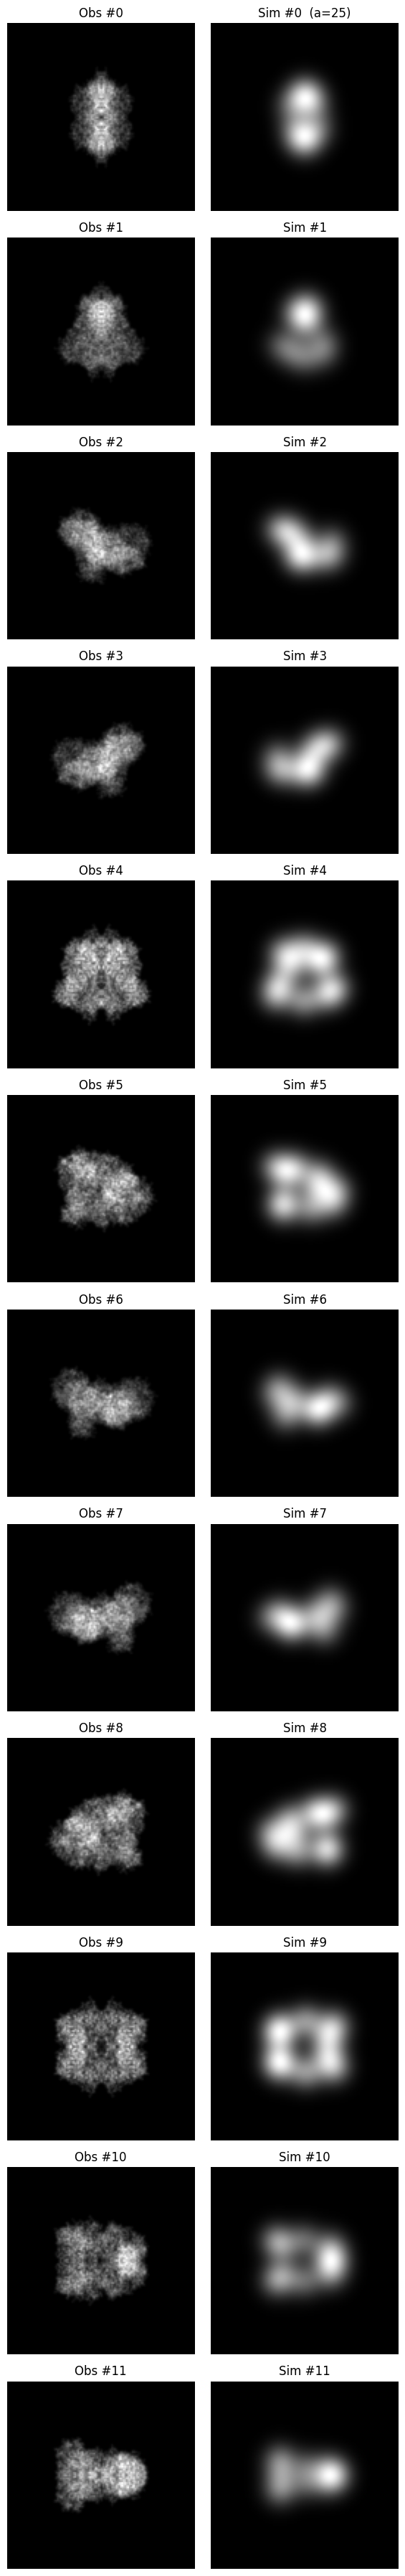

In [18]:
fig, pred, a = show_obs_vs_sim(I, theta_loc2, R_syms, sigma_pix=sigma_pix,
                               savepath="obs_vs_sim.png",
                               dpi=150, equal_scale=False, scale_pred=True)

In [19]:
import numpy as np
import mrcfile
from math import ceil

def symmetrize_points(mu3, R_syms):
    """
    mu3:    (K,3) centered coords (≈ around 0,0,0), float
    R_syms: (S,3,3) proper rotations
    return: (S*K,3) all symmetry-related copies
    """
    mu3 = np.asarray(mu3, dtype=np.float32)
    R_syms = np.asarray(R_syms, dtype=np.float32)
    # (S,3,3) @ (K,3)^T  -> (S,3,K) -> (S,K,3)
    sym = np.einsum('sij,kj->ski', R_syms, mu3)
    return sym.reshape(-1, 3)

def compute_global_scale(I_np, theta, sigma_pix, R_syms, eps=1e-12):
    """
    Compute a single multiplicative scale 'a' so that I ≈ a * pred
    over the whole stack (least squares).

    Returns
    -------
    a : float
    pred : np.ndarray of shape (N, X, Y)  (unscaled predictions)
    """
    I = np.asarray(I_np, dtype=np.float32)
    N, X, Y = I.shape

    # Render predictions (unscaled)
    P = np.array(render_gaussian_sum(theta, int(X), int(Y), float(sigma_pix),
                                     R_syms))  # (N,X,Y)

    num = float(np.sum(I * P))
    den = float(np.sum(P * P) + eps)
    a = num / den
    return a, P

def render_gaussian_volume_sym_windowed(theta, vol_shape,
                                        sigma_pix=2.0,
                                        R_syms=None,
                                        trunc_sigma=3.0,
                                        intensity=1.0):
    """
    Build a 3D density as a sum of isotropic Gaussians at (symmetrized) centers.

    Parameters
    ----------
    theta : dict
        {'mu3': (K,3)} in pixel units, centered (≈ -X/2..X/2, etc.).
    vol_shape : tuple of ints
        (X, Y, Z) volume size in pixels/voxels.
    sigma_pix : float
        Gaussian std-dev in pixels (same unit as mu3).
    R_syms : (S,3,3) array or None
        Symmetry rotations. If None, identity only.
    trunc_sigma : float
        Truncate/support radius in multiples of sigma (e.g., 3 → ±3σ).
    intensity : float
        Amplitude per Gaussian (all equal).

    Returns
    -------
    vol : np.ndarray, shape (X,Y,Z), float32
    """
    X, Y, Z = map(int, vol_shape)
    sigma = float(max(sigma_pix, 1e-6))
    r = int(ceil(trunc_sigma * sigma))  # support radius in voxels

    # Base centers
    mu3 = np.asarray(theta["mu3"], dtype=np.float32)  # (K,3)

    # Symmetrize (or identity)
    if R_syms is None:
        pts = mu3
    else:
        pts = symmetrize_points(mu3, R_syms)          # (M,3) with M=S*K

    # Convert centered coords to array indices by adding center
    center3 = np.array([X/2, Y/2, Z/2], dtype=np.float32)
    pts_idx = pts + center3[None, :]                  # (M,3) in [0..X-1] coords (float)

    vol = np.zeros((X, Y, Z), dtype=np.float32)
    inv2s2 = 0.5 / (sigma * sigma)

    # Add each Gaussian in a small cubic window
    for (xc, yc, zc) in pts_idx:
        # integer window bounds
        x0 = max(0, int(np.floor(xc)) - r); x1 = min(X, int(np.floor(xc)) + r + 1)
        y0 = max(0, int(np.floor(yc)) - r); y1 = min(Y, int(np.floor(yc)) + r + 1)
        z0 = max(0, int(np.floor(zc)) - r); z1 = min(Z, int(np.floor(zc)) + r + 1)
        if x0 >= x1 or y0 >= y1 or z0 >= z1:
            continue

        # local coordinate grids
        xs = np.arange(x0, x1, dtype=np.float32)
        ys = np.arange(y0, y1, dtype=np.float32)
        zs = np.arange(z0, z1, dtype=np.float32)
        Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")

        d2 = (Xg - xc)**2 + (Yg - yc)**2 + (Zg - zc)**2
        patch = intensity * np.exp(-inv2s2 * d2, dtype=np.float32)

        vol[x0:x1, y0:y1, z0:z1] += patch.astype(np.float32)

    return vol

def save_mrc(volume, path, voxel_size_ang=1.0, origin=(0.0, 0.0, 0.0)):
    """
    Save 3D numpy array to MRC format.
    """
    vol32 = np.asarray(volume, dtype=np.float32)
    with mrcfile.new(path, overwrite=True) as mrc:
        mrc.set_data(vol32)                     # (Z,Y,X) is also allowed; here we keep (X,Y,Z)
        # Set voxel size in Å (optional but recommended)
        try:
            # mrcfile >= 1.4 supports tuple assignment
            if isinstance(voxel_size_ang, (list, tuple, np.ndarray)):
                mrc.voxel_size = tuple(map(float, voxel_size_ang))
            else:
                mrc.voxel_size = float(voxel_size_ang)
        except Exception:
            pass
        # Set origin (optional)
        try:
            mrc.header.origin = np.array(origin, dtype=np.float32)
        except Exception:
            pass


In [20]:
Xdim = I.shape[2]
vol_shape = (Xdim, Xdim, Xdim)

# Build the 3D map
a = compute_global_scale(I, theta_loc2, sigma_pix, R_syms)[0]
vol = render_gaussian_volume_sym_windowed(theta_loc2, vol_shape,
                                          sigma_pix=sigma_pix,
                                          R_syms=R_syms,
                                          trunc_sigma=3.0,
                                          intensity=a)

# Save to MRC (set voxel size if you know it, e.g., 1.5 Å/px)
save_mrc(vol, "volume.mrc", voxel_size_ang=1.5, origin=(0.0, 0.0, 0.0))

In [22]:
print(max(I.ravel()),a)

123.4948 24.955104623715613
